# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
## Assignment Notebook: Federated Learning

## Learning Objectives

At the end of this assignment, you will be able to:

* Explain the fundamental concepts, architecture, and workflow of Federated Learning
* Differentiate the roles of clients and the central server in a federated learning system
* Partition a dataset across multiple simulated clients
* Implement local model training and evaluation on individual clients
* Configure and run a federated learning simulation using the Flower framework
* Apply the Federated Averaging strategy to combine client model updates
* Monitor training rounds and compare model performance across different client partitions

## **What is Federated Learning?**

**Federated Learning (FL)** is a machine learning approach in which multiple devices, organizations, or clients collaboratively train a shared model **without transferring their raw data to a central server**.

Each client trains the model locally using its own data and sends only model updates, such as gradients or updated parameters, to a central server. The server aggregates these updates to improve the global model and then distributes the updated model back to the clients.

For example, multiple hospitals can jointly train a disease-prediction model while keeping patient records within their own systems, helping improve data privacy and regulatory compliance.

---

### **Client and Server in Federated Learning**

**Client**

A **client** is a participating device, system, or organization that stores its own local data and trains the machine learning model using that data. Clients do not share their raw data with other participants or with the central server.

Examples of clients include:

* Mobile phones
* Hospitals
* Banks
* IoT devices
* Branch offices

**Server**

The **server** is the central coordinating system that manages the federated learning process. It distributes the global model to selected clients, receives their locally trained model updates, and combines these updates to create an improved global model.

The server generally does not access or store the clients’ raw training data.

---

## **How does Federated Learning work?**

### **Federated Learning in five steps**

**Step 0: Initialize global model**

We start by initializing the model on the server. This is exactly the same in classic centralized learning: we initialize the model parameters, either randomly or from a previously saved checkpoint.

<center>
<img src='https://flower.ai/docs/framework/_static/tutorial/fl-initialize-global-model.png' width=600px>
</center>



**Step 1: Send model to a number of connected organizations/devices (client nodes)**

Next, we send the parameters of the global model to the connected client nodes (think: edge devices like smartphones or servers belonging to organizations). This is to ensure that each participating node starts its local training using the same model parameters. We often use only a few of the connected nodes instead of all nodes. The reason for this is that selecting more and more client nodes has diminishing returns.

<center>
<img src='https://flower.ai/docs/framework/_static/tutorial/fl-send-global-model.png' width=600px>
</center>



**Step 2: Train model locally on the data of each organization/device (client node)**

Now that all (selected) client nodes have the latest version of the global model parameters, they start the local training. They use their own local dataset to train their own local model. They don’t train the model until full convergence, but they only train for a little while. This could be as little as one epoch on the local data, or even just a few steps (mini-batches).

<center>
<img src='https://flower.ai/docs/framework/_static/tutorial/fl-local-training.png' width=600px>
</center>



**Step 3: Return model updates back to the server**

After local training, each client node has a slightly different version of the model parameters they originally received. The parameters are all different because each client node has different examples in its local dataset. The client nodes then send those model updates back to the server. The model updates they send can either be the full model parameters or just the gradients that were accumulated during local training.

<center>
<img src='https://flower.ai/docs/framework/_static/tutorial/fl-send-model-updates.png' width=600px>
</center>



**Step 4: Aggregate model updates into a new global model**

The server receives model updates from the selected client nodes. If it selected 100 client nodes, it now has 100 slightly different versions of the original global model, each trained on the local data of one client.

In order to get one single model, we have to combine all the model updates we received from the client nodes. This process is called **aggregation**, and there are many different ways to do it. The most basic way is called Federated Averaging.

> **Federated Averaging (FedAvg)**
>
>  FedAvg takes the model updates (received from the selected client nodes) and, averages them. To be more precise, it takes the weighted average of the model updates, weighted by the number of examples each client used for training.
>
> The combining step is simple math:
>
> $$
w_{\text{global}} = \sum_{k=1}^{K} \frac{n_k}{n} \cdot w_k
$$
>
> where $n_k$ is the number of training samples on client $k$ and $n = \sum_{k=1}^{K} n_k$.
>
> The weighting is important to make sure that each data example has the same “influence” on the resulting global model. If one client has 10 examples, and another client has 100 examples, then - without weighting - each of the 10 examples would influence the global model ten times as much as each of the 100 examples.

<center>
<img src='https://flower.ai/docs/framework/_static/tutorial/fl-aggregate-model-updates.png' width=600px>
</center>



**Step 5: Repeat steps 1 to 4 until the model converges**

> **Round**
>
> Steps 1 to 4 are what we call a *single round of federated learning*.
>
>   - **Broadcasting:** the global model parameters get sent to the participating client nodes (step 1)
>
> - **Local Training:** the client nodes train on their local data (step 2)
>
> - **Uploading:** they send their updated models to the server (step 3)
>
> - **Aggregation:** the server then aggregates the model updates to get a new version of the global model (step 4)

During a single round, each client node that participates in that iteration only trains for a little while. This means that after the aggregation step (step 4), we have a model that has been trained on all the data of all participating client nodes, but only for a little while. We then have to **repeat this training process over and over again** to eventually arrive at a fully trained model that performs well across the data of all client nodes.


### **Visualization of the full Federated Learning Round**

<center>
<img src='https://raw.githubusercontent.com/MLOPS-test/Artifacts/refs/heads/main/images/Federated_Learning_arch.png' width=750px>
</center>

### **Federated Learning on Mobile Devices**

The following figure shows how multiple phones begin with the same model and learn from different local typing patterns, such as code-switching, formal English, or medical vocabulary.

Each device sends only model weight updates to the aggregation server, which combines them using a weighted average and redistributes an improved global model that captures knowledge from all participating devices without sharing their raw text.


<center>
<img src='https://raw.githubusercontent.com/MLOPS-test/Artifacts/refs/heads/main/images/Federated_Learning_example.png' width=750px>
</center>

## **Flower Framework**

Federated learning require infrastructure to

- move machine learning models back and forth,
- train and evaluate them on local data, and
- then aggregate the updated models.

**Flower** provides the infrastructure to do exactly that in an easy, scalable, and secure way.

In short, Flower presents a unified approach to federated learning, analytics, and evaluation. It allows the user to federate any workload, any ML framework, and any programming language.

## **1. Model Building using PyTorch - Quick recap**

Review the ***Model_Building_using_PyTorch.ipynb*** notebook to refresh the key steps involved in defining, training, and evaluating a neural network. This recap will help you understand the local model training performed by each client in the Federated Learning workflow.


## **2. Why Federated Learning? - Demonstration**

In this demonstration, the MNIST dataset is divided into three client-specific partitions. Three selected digit classes are removed from each partition to simulate clients having different and incomplete local data distributions.

A separate model is trained on each partition and evaluated using both the complete test dataset and the test samples belonging to the missing digit classes. The results demonstrate that models trained independently on limited local data may perform well on familiar classes but struggle to recognize classes that were absent during training. This highlights the need for Federated Learning, where clients collaboratively train a shared global model while keeping their local data private.


**MNIST Dataset**

The MNIST dataset (Modified National Institute of Standards and Technology database) is **a large database of handwritten digits** that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning. The MNIST database contains 60,000 training images and 10,000 testing images. Each image is a 28 by 28 pixel square (784 pixels total)


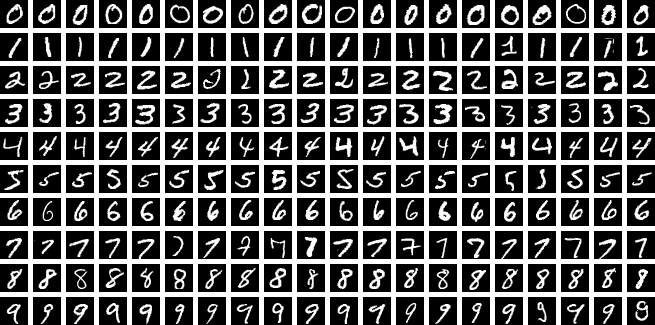

### **Setup Steps:**

In [ ]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "" #@param {type:"string"}

In [ ]:
#@title Please enter your password (your registered phone number) to continue: { run: "auto", display-mode: "form" }
password = "" #@param {type:"string"}

In [ ]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython
from IPython.display import HTML, display

ipython = get_ipython()

notebook= "M10_AST_01_Federated_Learning"   #name of the notebook

batchId = "IISC-AC-GENAI-02"


def print_message(message: str, color: str = "red"):
    display(HTML(f"<span style='color:{color};'>{message}</span>"))

def setup():
#  ipython.magic("sx pip3 install torch")

    from IPython.display import HTML, display
    display(HTML('<script src="https://dashboard.talentsprint.com/submissions/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(), "batch" : batchId}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print_message(r["err"])
        return None
      else:
        print_message("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook,
              "feedback_experiments_input" : Comments,
              "feedback_mentor_support": Mentor_support,
              "batch" : batchId
            }
      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iisc.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


# def getWalkthrough():
#   try:
#     if not Walkthrough:
#       raise NameError
#     else:
#       return Walkthrough
#   except NameError:
#     print ("Please answer Walkthrough Question")
#     return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")

### Install Required Libraries

In [ ]:
%%capture
!pip -q install flwr==1.31.0  # Install the Flower framework for building and running federated learning applications
!pip -q install ray           # Install Ray, which Flower uses to simulate multiple federated learning clients
!pip -q install "flwr-datasets[vision]"  # Install Flower Datasets with vision dependencies for loading and partitioning image datasets

### Import Required Packages

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Subset, DataLoader, random_split
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

# Prevent Ray from overriding accelerator-related environment variables when their value is set to zero.
import os
os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#### Load the MNIST dataset

* Load the MNIST dataset using the `datasets.MNIST` function

In [ ]:
# Define the preprocessing steps to be applied to each MNIST image
transform = transforms.Compose(
    [
        transforms.ToTensor(),                # Convert the image into a PyTorch tensor with pixel values between 0 and 1
        transforms.Normalize((0.5,), (0.5,)), # Normalize the grayscale pixel values from [0, 1] to approximately [-1, 1]
    ]
)

# Download and load the MNIST training dataset
trainset = datasets.MNIST(
    root="./MNIST_data/",  # Directory where the dataset will be stored
    download=True,         # Download the dataset if it is not already available
    train=True,            # Load the training split of the MNIST dataset
    transform=transform,   # Apply the defined preprocessing steps to each image
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.06MB/s]


In [ ]:
trainset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./MNIST_data/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

* Split the training dataset to three datasets for this example

In [ ]:
total_length = len(trainset)     # Get the total number of samples available in the MNIST training dataset
split_size = total_length // 3   # Calculate the number of samples to include in each of the three partitions
torch.manual_seed(42)            # Set a fixed random seed to ensure reproducible dataset partitions

# Randomly divide the training dataset into three equal-sized client partitions
part1, part2, part3 = random_split(
    trainset,
    [split_size] * 3,
)

* Set the three different datasets, excluding some digits as shown in the explanation.
    - `part1` excludes digits 1, 3, and 7.
    - `part2` excludes digits 2, 5, and 8.
    - `part3` excludes digits 4, 6, and 9.

    This simulates the different datasets that might be available in real world (datasets with missing data, extra data, etc).

In [ ]:
def exclude_digits(dataset, excluded_digits):
    # Identify the indices of samples whose labels are not in the excluded list
    including_indices = [
        idx for idx in range(len(dataset)) if dataset[idx][1] not in excluded_digits
    ]
    # Create and return a new dataset containing only the selected samples
    return torch.utils.data.Subset(dataset, including_indices)

In [ ]:
# Remove samples of digits 1, 3, and 7 from the first client partition
part1 = exclude_digits(part1, excluded_digits=[1, 3, 7])

# Remove samples of digits 2, 5, and 8 from the second client partition
part2 = exclude_digits(part2, excluded_digits=[2, 5, 8])

# Remove samples of digits 4, 6, and 9 from the third client partition
part3 = exclude_digits(part3, excluded_digits=[4, 6, 9])

* Plot the three datasets

In [ ]:
def plot_distribution(dataset, title):
    # Extract the class label from each sample in the dataset
    labels = [data[1] for data in dataset]

    # Find the unique digit labels and count how many samples belong to each label
    unique_labels, label_counts = torch.unique(
        torch.tensor(labels),
        return_counts=True,
    )

    # Create a figure for the digit distribution chart
    plt.figure(figsize=(4, 2))

    # Store each available digit and its corresponding sample count
    counts_dict = {
        label.item(): count.item()
        for label, count in zip(unique_labels, label_counts)
    }

    # Define all possible MNIST digit labels from 0 to 9
    all_labels = np.arange(10)

    # Retrieve the count for every digit and assign 0 to missing digits
    all_label_counts = [
        counts_dict.get(label, 0)
        for label in all_labels
    ]

    # Plot the number of samples available for each digit
    plt.bar(all_labels, all_label_counts)

    plt.title(title)
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.xticks(all_labels)
    plt.show()

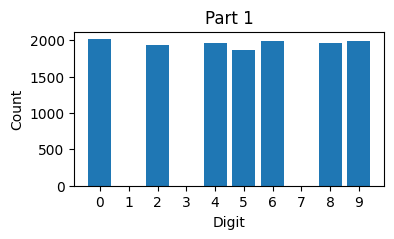

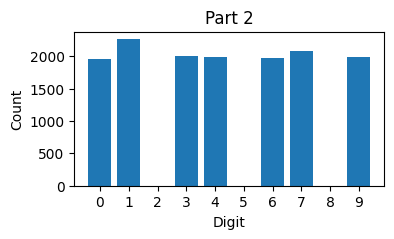

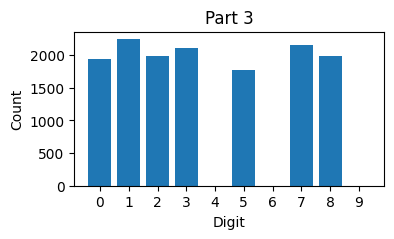

In [ ]:
# Visualize the digit distribution in each partition

plot_distribution(part1, "Part 1")
plot_distribution(part2, "Part 2")
plot_distribution(part3, "Part 3")

#### Train and test the models

* Define three and run the models

    Three instances of the `NeuralNetworkModel` class (`model1`, `model2`, `model3`) are created for training.

In [ ]:
# Define a fully connected neural network for classifying MNIST digits into 10 classes

class NeuralNetworkModel(nn.Module):
    def __init__(self):
        super(NeuralNetworkModel, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.relu = nn.ReLU()
        self.out = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.out(x)
        return x

In [ ]:
def train_model(model, train_set):
    batch_size = 64        # Define the number of samples processed in each training batch
    num_epochs = 10        # Define the number of times the model will iterate over the complete dataset

    # Create a DataLoader to load the training data in shuffled mini-batches
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()           # Define the loss function for multi-class classification
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)    # Configure the SGD optimizer

    model.train()                               # Set the model to training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()               # Clear gradients calculated during the previous iteration
            outputs = model(inputs)             # Perform a forward pass to generate predictions
            loss = criterion(outputs, labels)   # Calculate the classification loss
            loss.backward()                     # Perform backpropagation to calculate gradients
            optimizer.step()                    # Update the model parameters
            running_loss += loss.item()         # Add the current batch loss to the running total

        print(f"Epoch {epoch + 1}: Loss = {running_loss / len(train_loader)}")

    print("Training complete")

In [ ]:
# Initialize and train three separate neural network models using their respective client-specific data partitions

print("\nTraining `model1` on `part1` data")
model1 = NeuralNetworkModel()
train_model(model1, part1)

print("\nTraining `model2` on `part2` data")
model2 = NeuralNetworkModel()
train_model(model2, part2)

print("\nTraining `model3` on `part3` data")
model3 = NeuralNetworkModel()
train_model(model3, part3)


Training `model1` on `part1` data
Epoch 1: Loss = 0.6472279275226038
Epoch 2: Loss = 0.24024201309265092
Epoch 3: Loss = 0.18977103054870006
Epoch 4: Loss = 0.15037704415099565
Epoch 5: Loss = 0.12479810810886151
Epoch 6: Loss = 0.10187328570024219
Epoch 7: Loss = 0.08095997116680062
Epoch 8: Loss = 0.07000003997019903
Epoch 9: Loss = 0.05634645269317336
Epoch 10: Loss = 0.05328233436746306
Training complete

Training `model2` on `part2` data
Epoch 1: Loss = 0.5202773362730763
Epoch 2: Loss = 0.18201332115235605
Epoch 3: Loss = 0.15168895062691132
Epoch 4: Loss = 0.13265217159641907
Epoch 5: Loss = 0.10417876047514645
Epoch 6: Loss = 0.08734426122932096
Epoch 7: Loss = 0.07453832495749728
Epoch 8: Loss = 0.062238159186173495
Epoch 9: Loss = 0.05836537331509005
Epoch 10: Loss = 0.05187160594505258
Training complete

Training `model3` on `part3` data
Epoch 1: Loss = 0.6342176325820588
Epoch 2: Loss = 0.2545813501787347
Epoch 3: Loss = 0.184374541866484
Epoch 4: Loss = 0.1457465965644800

#### Evaluate the Models

* Load the test dataset

In [ ]:
testset = datasets.MNIST(
    "./MNIST_data/", download=True, train=False, transform=transform
)

print("Number of examples in `testset`:", len(testset))

Number of examples in `testset`: 10000


In [ ]:
testset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./MNIST_data/
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

* Dataset preparation:
   - `testset_137` includes digits 1, 3, and 7.
   - `testset_258` includes digits 2, 5, and 8.
   - `testset_469` includes digits 4, 6, and 9.

In [ ]:
def include_digits(dataset, included_digits):
    including_indices = [
        idx for idx in range(len(dataset)) if dataset[idx][1] in included_digits
    ]
    return torch.utils.data.Subset(dataset, including_indices)

In [ ]:
# Create test subsets containing only the digit groups excluded from each corresponding client’s training data
testset_137 = include_digits(testset, included_digits=[1, 3, 7])
testset_258 = include_digits(testset, included_digits=[2, 5, 8])
testset_469 = include_digits(testset, included_digits=[4, 6, 9])

* Evaluate the models with the test datasets

    The `evaluate_model` function is called to evaluate each model defined above (`model1`, `model2`, `model3`) on both, the entire test dataset and specific subsets of the test dataset.

In [ ]:
def evaluate_model(model, test_set):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0
    total_loss = 0

    # Create a DataLoader to process the test data in batches without shuffling
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():                   # Disable gradient calculation to reduce memory usage during evaluation
        for inputs, labels in test_loader:
            outputs = model(inputs)                        # Generate model predictions
            _, predicted = torch.max(outputs.data, 1)      # Select the class with the highest predicted score
            total += labels.size(0)                        # Update the total number of evaluated samples
            correct += (predicted == labels).sum().item()  # Count the number of correct predictions

            # Calculate and accumulate the loss for the current batch
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    accuracy = correct / total                    # Calculate the overall classification accuracy
    average_loss = total_loss / len(test_loader)  # Calculate the average loss across all test batches

    return average_loss, accuracy

In [ ]:
# Evaluate each model on the complete test set and
# on the digit classes excluded from its corresponding training partition.

_, accuracy1 = evaluate_model(model1, testset)
_, accuracy1_on_137 = evaluate_model(model1, testset_137)
print(
    f"Model 1-> Test Accuracy on all digits: {accuracy1:.4f}, "
    f"Test Accuracy on [1,3,7]: {accuracy1_on_137:.4f}"
)

_, accuracy2 = evaluate_model(model2, testset)
_, accuracy2_on_258 = evaluate_model(model2, testset_258)
print(
    f"Model 2-> Test Accuracy on all digits: {accuracy2:.4f}, "
    f"Test Accuracy on [2,5,8]: {accuracy2_on_258:.4f}"
)

_, accuracy3 = evaluate_model(model3, testset)
_, accuracy3_on_469 = evaluate_model(model3, testset_469)
print(
    f"Model 3-> Test Accuracy on all digits: {accuracy3:.4f}, "
    f"Test Accuracy on [4,6,9]: {accuracy3_on_469:.4f}"
)

Model 1-> Test Accuracy on all digits: 0.6515, Test Accuracy on [1,3,7]: 0.0000
Model 2-> Test Accuracy on all digits: 0.6893, Test Accuracy on [2,5,8]: 0.0000
Model 3-> Test Accuracy on all digits: 0.6820, Test Accuracy on [4,6,9]: 0.0000


**Observation:** Each model achieves only moderate accuracy on the complete test dataset because it was trained on an incomplete local data distribution. The accuracy drops to **0% for the excluded digit classes**, showing that an independently trained client model cannot recognize classes it has never encountered. This highlights the need for federated training to combine knowledge learned across clients.


* Analyze the results by checking the 'confusion matrix' for the three models just trained using the ```compute_confusion_matrix```.

In [ ]:
# Generate a confusion matrix to compare the model’s predicted digit classes with the actual labels

def compute_confusion_matrix(model, testset):
    # Initialize lists to store true labels and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over the test set to get predictions
    for image, label in testset:
        # Forward pass through the model to get predictions
        output = model(image.unsqueeze(0))  # Add batch dimension
        _, predicted = torch.max(output, 1)

        # Append true and predicted labels to lists
        true_labels.append(label)
        predicted_labels.append(predicted.item())

    # Convert lists to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    return cm

In [ ]:
# Visualize the confusion matrix as a heatmap to compare actual and predicted digit labels

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=0.5)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

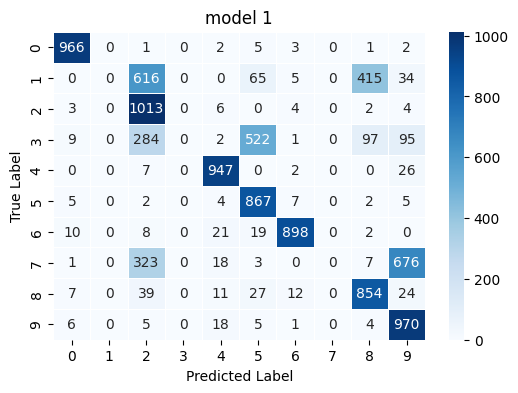

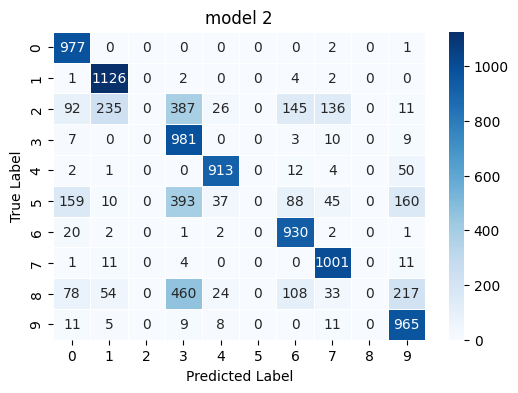

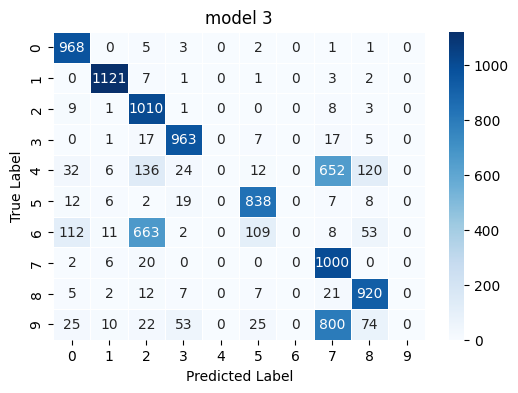

In [ ]:
# Compute and visualize the confusion matrices of all three models on the complete MNIST test dataset

confusion_matrix_model1_all = compute_confusion_matrix(model1, testset)
confusion_matrix_model2_all = compute_confusion_matrix(model2, testset)
confusion_matrix_model3_all = compute_confusion_matrix(model3, testset)

plot_confusion_matrix(confusion_matrix_model1_all, "model 1")
plot_confusion_matrix(confusion_matrix_model2_all, "model 2")
plot_confusion_matrix(confusion_matrix_model3_all, "model 3")

**Observation:** Each model performs well on the digit classes present in its own training partition but completely fails to predict the excluded classes, as shown by the empty diagonal cells for those digits. The misclassified samples are redirected to other known classes, confirming that independently trained client models have limited knowledge due to incomplete local data.


---
---

## **3. Federated Training Process**

Steps involved:

- Define functions to `set_weights` and `get_weights`

- Setup Client
    - Create `FlowerClient` class
    - Define `client_fn` function
    - Create `ClientApp` instance

- Setup Server
    - Define `evaluate` function
    - Define `server_fn` function (strategy: FedAvg)
    - Create `ServerApp` instance

- Run the Federated Learning Simulation (`run_simulation`)

#### Import Required Packages

In [ ]:
from flwr.client import Client, ClientApp, NumPyClient
from flwr.common import ndarrays_to_parameters, Context
from flwr.server import ServerApp, ServerConfig
from flwr.server import ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
from collections import OrderedDict
from typing import List, Tuple, Dict, Optional
from flwr.common import Metrics, NDArrays, Scalar
import logging
from flwr.common.logger import console_handler, log
from logging import INFO, ERROR

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#### Define Training and Testing in the pipeline

* **Set functions for the client-server exchange of the training information**

    These helper functions enable the exchange of model parameters between Flower clients and the server.
    - `get_weights()` converts a model’s parameters into NumPy arrays for transmission and aggregation,
    - while `set_weights()` loads the received parameters back into the PyTorch model for training or evaluation.


In [ ]:
# Sets the parameters of the model

def set_weights(net, parameters):
    params_dict = zip(net.state_dict().keys(), parameters)    # Match each model state-dictionary key with its corresponding parameter array
    state_dict = OrderedDict(                                 # Convert the parameter arrays into PyTorch tensors stored in an ordered dictionary
        {k: torch.tensor(v) for k, v in params_dict}
    )
    net.load_state_dict(state_dict, strict=True)              # Update the model with the provided parameters


# Retrieves the parameters from the model

def get_weights(net):
    # Move each parameter tensor to the CPU and convert it into a NumPy array
    ndarrays = [
        val.cpu().numpy() for _, val in net.state_dict().items()
    ]
    return ndarrays        # Return the parameters for sharing or aggregation


#### **Setup Client**

* **Connect the training in the pipeline using the Flower Client**

    This `FlowerClient` class connects each local client’s model and dataset to the Flower federated learning workflow. The `fit()` method receives the current global parameters, trains the model on the client’s local data, and returns the updated weights, while `evaluate()` tests the received global model on the client’s local test data and reports the loss and accuracy.


In [ ]:
class FlowerClient(NumPyClient):
    def __init__(self, net, trainset, testset):
        self.net = net
        self.trainset = trainset
        self.testset = testset

    # Train the model
    def fit(self, parameters, config):
        set_weights(self.net, parameters)
        train_model(self.net, self.trainset)
        return get_weights(self.net), len(self.trainset), {}

    # Test the model
    def evaluate(self, parameters: NDArrays, config: Dict[str, Scalar]):
        set_weights(self.net, parameters)
        loss, accuracy = evaluate_model(self.net, self.testset)
        return loss, len(self.testset), {"accuracy": accuracy}

* **Flower calls `client_fn` whenever it needs an instance of one particular client to call fit or evaluate**

    The `client_fn()` function creates a Flower client for a specific partition. It initializes a new neural network, reads the client’s `partition-id` from the simulation context, assigns the corresponding local training dataset, and returns the configured `FlowerClient`.

    The `ClientApp` then registers this function with Flower, allowing the framework to create the required client instances dynamically during federated training and evaluation.


In [ ]:
# Store the three client-specific training datasets in a list
train_sets = [part1, part2, part3]


# Define a function that creates and configures a Flower client
def client_fn(context: Context) -> Client:
    net = NeuralNetworkModel()                   # Initialize a new neural network model for the client
    partition_id = int(context.node_config["partition-id"])     # Retrieve the client partition ID assigned by Flower
    client_train = train_sets[partition_id]      # Select the corresponding local training dataset
    client_test = testset                        # Use the complete test dataset for local evaluation

    # Create the Flower client and convert it to the required Client type
    return FlowerClient(net, client_train, client_test).to_client()


* **Create an instance of the ClientApp**

In [ ]:
# Create the Flower ClientApp using the client factory function
client = ClientApp(client_fn)

#### **Setup Server**

* **Define `evaluate` for testing**

    The server-side `evaluate()` function loads the latest aggregated global parameters into a new neural network and evaluates its performance on the complete MNIST test set as well as the three missing-digit subsets. It logs the accuracy after each federated round and, after the final round, generates a confusion matrix to visualize the global model’s class-wise performance.


In [ ]:
def evaluate(server_round, parameters, config):
    net = NeuralNetworkModel()          # Initialize a new neural network model for server-side evaluation
    set_weights(net, parameters)        # Load the latest aggregated global parameters into the model

    # Evaluate the global model on the complete MNIST test dataset
    _, accuracy = evaluate_model(net, testset)

    # Evaluate the global model on each missing-digit test subset
    _, accuracy137 = evaluate_model(net, testset_137)
    _, accuracy258 = evaluate_model(net, testset_258)
    _, accuracy469 = evaluate_model(net, testset_469)

    # Log the evaluation accuracy on the complete test dataset, as well as for each selected digit group
    log(INFO, "test accuracy on all digits: %.4f", accuracy)
    log(INFO, "test accuracy on [1,3,7]: %.4f", accuracy137)
    log(INFO, "test accuracy on [2,5,8]: %.4f", accuracy258)
    log(INFO, "test accuracy on [4,6,9]: %.4f", accuracy469)

    # Generate and display the confusion matrix after the final federated round
    if server_round == 3:
        cm = compute_confusion_matrix(net, testset)
        plot_confusion_matrix(cm, "Final Global Model")


* **Strategy: Federated Average 'FedAvg'**

    The below code initializes the global neural network parameters and configures the server to use the **Federated Averaging (`FedAvg`)** strategy.
    
    In every round, all available clients participate in training (`fraction_fit=1.0`), their model updates are aggregated into a new global model, and the server-side `evaluate()` function measures its performance.

    The `ServerConfig(num_rounds=3)` setting runs federated training for three communication rounds, while `fraction_evaluate=0.0` disables client-side evaluation because evaluation is handled centrally on the server.


In [ ]:
# Initialize the global neural network model
net = NeuralNetworkModel()

# Convert the model weights from NumPy arrays into Flower Parameters
params = ndarrays_to_parameters(get_weights(net))


# Define the Flower server configuration
def server_fn(context: Context):
    # Configure the Federated Averaging strategy
    strategy = FedAvg(
        fraction_fit=1.0,          # Select all available clients for training
        fraction_evaluate=0.0,     # Disable client-side evaluation
        initial_parameters=params, # Set the initial global model parameters
        evaluate_fn=evaluate,      # Use the server-side evaluation function
    )

    # Configure the number of federated training rounds
    config = ServerConfig(num_rounds=3)

    # Return the server strategy and configuration
    return ServerAppComponents(
        strategy=strategy,
        config=config,
    )

* **Create an instance of ServerApp**

    The below code creates the Flower `ServerApp` using the `server_fn` function.
    
    The `ServerApp` manages the server-side federated learning workflow, including the aggregation strategy, training rounds, and evaluation of the global model.


In [ ]:
# Create the Flower ServerApp using the server configuration function
server = ServerApp(server_fn=server_fn)

#### **Run the Federated Learning Simulation**

Start the Flower simulation by connecting the configured `ServerApp` and `ClientApp` with three simulated clients.

During each training round,

- the clients train their local models,
- send updated parameters to the server, and
- the server aggregates them using the FedAvg strategy to update and evaluate the global model.



*(The below code cell might take 5-10 minutes to execute.)*


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
DEBUG:flwr:backend_config: {'init_args': {'logging_level': 40, 'log_to_driver': False}}
DEBUG:flwr:Asyncio event loop already running.
INFO :      Starting Flower ServerApp, config: num_rounds=3, no round_timeout
INFO :      
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      test accuracy on all digits: 0.0840
/usr/local/lib/p

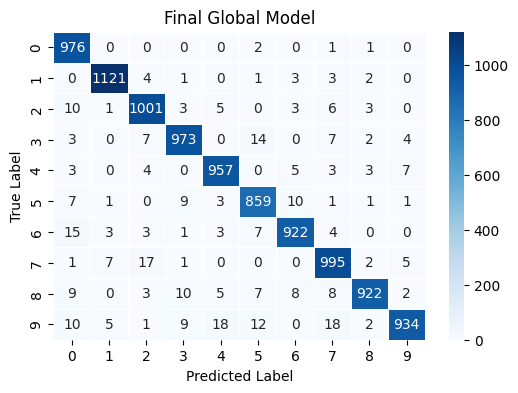

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 539.13s
INFO :      
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Start the federated learning simulation using the configured server and client applications

run_simulation(
    server_app=server,   # Use the configured Flower ServerApp
    client_app=client,   # Use the configured Flower ClientApp
    num_supernodes=3,    # Simulate three federated learning clients
    backend_config={
        "init_args": {
            "logging_level": ERROR,  # Display only error-level backend logs
            "log_to_driver": False,  # Prevent worker logs from being forwarded to the main process
        }
    },
)

**Observation:** The global model improves consistently across the three federated rounds, with overall test accuracy increasing from **~87%** in Round 1 to **~96%** in Round 3. It also achieves high accuracy on all previously missing digit groups, demonstrating that Federated Averaging successfully combines the knowledge learned from different clients.

The final confusion matrix shows strong values along the diagonal for all digits, confirming that the aggregated global model can recognize every class much better than the independently trained client models.


---
---

## **4. Incorporating Data Privacy**


#### **Differential Privacy**

Differential privacy (DP) is often mentioned in the context of Federated Learning. It is a privacy-preserving method used when analyzing and sharing statistical data, ensuring the privacy of individual participants.

DP achieves this by **adding statistical noise to the model updates**, ensuring any individual participants’ information cannot be distinguished or re-identified. This technique can be considered an optimization that provides a quantifiable privacy protection measure.

**How Data Privacy imcorporated?**

Data privacy is incorporated by applying client-side Differential Privacy during federated training. The MNIST dataset is divided across 10 clients, and each client trains the model using only its local data. Before the model updates are shared with the server, the `adaptiveclipping_mod` limits the magnitude of the updates to reduce the influence of any individual training sample.

The standard FedAvg strategy is then wrapped using `DifferentialPrivacyClientSideAdaptiveClipping`. During aggregation, calibrated Gaussian noise is added to the clipped client updates using the specified `noise_multiplier`. In each round, 6 out of 10 clients participate in training, and their privacy-protected updates are combined to produce the global model. This approach improves privacy by making it more difficult to infer information about individual records from the shared model updates.


In [ ]:
# Import the adaptive clipping modifier for client-side differential privacy
from flwr.client.mod import adaptiveclipping_mod

# Import the standard FedAvg strategy and its differentially private wrapper
from flwr.server.strategy import (
    DifferentialPrivacyClientSideAdaptiveClipping,
    FedAvg,
)

* **Split the MNIST dataset into 10 parts**

    The below code divides the 60,000 MNIST training samples into **10 equal partitions of 6,000 samples each**, representing data distributed across 10 federated clients. The fixed random seed ensures that the same client partitions are generated whenever the code is executed.


In [ ]:
total_length = len(trainset)
split_size = total_length // 10
torch.manual_seed(42)
all_10_train_sets = random_split(trainset, [split_size] * 10)

In [ ]:
total_length

60000

In [ ]:
len(all_10_train_sets[0])

6000

#### **Setup Client with DP**

* **Define the FlowerClient**

In [ ]:
class FlowerClient(NumPyClient):
    def __init__(self, net, trainset, testset):
        self.net = net
        self.trainset = trainset
        self.testset = testset

    # Train the model
    def fit(self, parameters, config):
        set_weights(self.net, parameters)
        train_model(self.net, self.trainset)
        return get_weights(self.net), len(self.trainset), {}

    # Test the model
    def evaluate(self, parameters: NDArrays, config: Dict[str, Scalar]):
        set_weights(self.net, parameters)
        loss, accuracy = evaluate_model(self.net, self.testset)
        return loss, len(self.testset), {"accuracy": accuracy}

* **Define `client_fn`**

    Flower calls `client_fn` whenever it needs an instance of one particular client to call fit or evaluate.

In [ ]:
# Client function
def client_fn(context: Context) -> Client:
    net = NeuralNetworkModel()
    partition_id = int(context.node_config["partition-id"])
    client_train = all_10_train_sets[int(partition_id)]
    client_test = testset
    return FlowerClient(net, client_train, client_test).to_client()

* **Define the ClientApp**

In [ ]:
# Create the Flower ClientApp and apply adaptive clipping to client model updates for differential privacy
client_with_dp = ClientApp(
    client_fn,                    # Function used to create each federated client
    mods=[adaptiveclipping_mod],  # Clip client updates before they are sent to the server
)

#### **Setup Server with DP**

* **Define `evaluate()` for testing**

In [ ]:
def evaluate(server_round, parameters, config):
    net = NeuralNetworkModel()          # Initialize a new neural network model for server-side evaluation
    set_weights(net, parameters)        # Load the latest aggregated global parameters into the model

    # Evaluate the global model on the complete MNIST test dataset
    _, accuracy = evaluate_model(net, testset)

    # Log the evaluation accuracy on the complete test dataset
    log(INFO, "test accuracy on all digits: %.4f", accuracy)

    # Generate and display the confusion matrix after the final federated round
    if server_round == 5:
        cm = compute_confusion_matrix(net, testset)
        plot_confusion_matrix(cm, "Final Global Model")


* **Define the Server side with the strategy FedAvg with DP**

    **DP:** Differential Privacy

In [ ]:
# Initialize the global neural network model
net = NeuralNetworkModel()

# Convert the initial model weights into Flower-compatible parameters
params = ndarrays_to_parameters(get_weights(net))


# Define the Flower server configuration with differential privacy
def server_fn_with_dp(context: Context):
    # Configure the standard Federated Averaging strategy
    fedavg_without_dp = FedAvg(
        fraction_fit=0.6,          # Select 60% of available clients for training
        fraction_evaluate=1.0,     # Select all available clients for evaluation
        initial_parameters=params, # Set the initial global model parameters
        evaluate_fn=evaluate,      # Use the server-side evaluation function
    )

    # Wrap FedAvg with client-side adaptive clipping and differential privacy
    fedavg_with_dp = DifferentialPrivacyClientSideAdaptiveClipping(
        fedavg_without_dp,         # Base aggregation strategy
        noise_multiplier=0.3,      # Control the amount of noise added for privacy
        num_sampled_clients=6,     # Expected number of clients selected per round
    )

    # Configure the federated learning process to run for five rounds
    config = ServerConfig(num_rounds=5)

    # Return the privacy-enabled strategy and server configuration
    return ServerAppComponents(
        strategy=fedavg_with_dp,
        config=config,
    )

In [ ]:
# Create the Flower ServerApp using the differential privacy-enabled server configuration
server_with_dp = ServerApp(server_fn=server_fn_with_dp)

#### **Run the Federated Learning Simulation**

*(The below code cell might take 10-15 minutes to execute.)*


            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=5, no round_timeout
INFO :      
INFO :      [INIT]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      test accuracy on all digits: 0.0938
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 6 clients (out of 10)
INFO :      aggregate_fit: received 6 results and 0 failures
INFO :      aggregate_fit: central DP noise with 0.0052 std

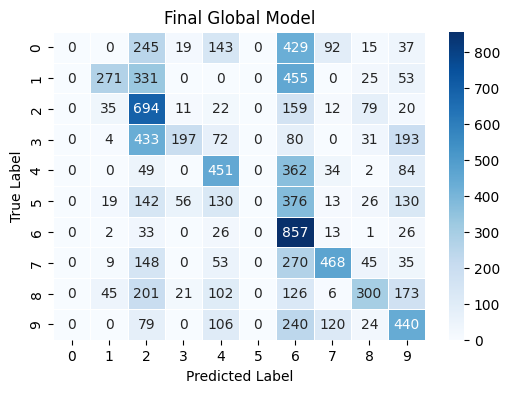

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)
INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 915.13s
INFO :      	History (loss, distributed):
INFO :      		round 1: 2.2895744712489425
INFO :      		round 2: 2.2742686863917454
INFO :      		round 3: 2.2581005339409894
INFO :      		round 4: 2.2367478237030616
INFO :      		round 5: 2.216814262851788
INFO :      
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aw

In [ ]:
# Run the differential privacy-enabled federated learning simulation with 10 simulated clients

run_simulation(
    server_app=server_with_dp,   # Use the privacy-enabled Flower ServerApp
    client_app=client_with_dp,   # Use the ClientApp with adaptive clipping applied
    num_supernodes=10,           # Simulate 10 federated learning clients
    backend_config={
        "init_args": {
            "logging_level": ERROR,  # Display only error-level backend logs
            "log_to_driver": False,  # Prevent worker logs from being forwarded to the main process
        }
    },
)

**Observation:** With Differential Privacy enabled, the global model accuracy improves gradually from **~11% in Round 1 to ~36% in Round 5**, while noise is added to the aggregated updates in every round. The confusion matrix shows that the model has started learning several digit classes, but performance remains much lower than the non-private model because the added noise and limited client participation reduce learning effectiveness. This demonstrates the typical **privacy–utility trade-off** in differentially private federated learning.


## **Where Federated Learning Can Be Applied**

Federated Learning is useful in situations where multiple devices or organizations need to collaboratively train a model but cannot directly share their raw data. The appropriate FL design depends on the number and type of participants, data distribution, privacy requirements, communication constraints, model size, and level of trust among clients.


### Scenario 1: Collaborative Fraud Detection Across Banks

Multiple banks can jointly train a fraud-detection model using their individual transaction records without transferring customer data outside their own systems. Since the participants are a small number of stable organizations, this is a **cross-silo Federated Learning** use case.

Secure aggregation can prevent banks from viewing one another’s individual model updates, while Differential Privacy may be added for further protection. Standard Federated Averaging is generally suitable because the banks have reliable infrastructure and can participate consistently.


### Scenario 2: Personalized Keyboard Prediction on Mobile Devices

A keyboard application installed on millions of smartphones can improve next-word prediction by learning from users’ local typing patterns, languages, and writing styles. Messages remain on the device, while only privacy-protected model updates are shared.

This is a **cross-device Federated Learning** use case because it involves a very large number of intermittently available devices. Differential Privacy, secure aggregation, client selection, quantization, and update compression are important because of privacy, battery, bandwidth, and connectivity constraints.


### Scenario 3: Federated Fine-Tuning of Enterprise LLMs

A SaaS provider can improve a shared language model using support tickets stored within each customer’s private cloud or VPC. Each enterprise trains the model locally so that confidential business data never leaves its environment.

This is a **cross-silo Federated Learning** scenario involving multiple enterprise customers. Since transferring the complete weights of a large language model would be inefficient, techniques such as **Federated LoRA** can be used to train and exchange only small adapter parameters. Secure aggregation can provide an additional layer of protection.


### Scenario 4: Collaborative Medical Research Across Hospitals

Hospitals can jointly train diagnostic or tumor-classification models using locally stored medical images without sharing sensitive patient records. This enables broader and more diverse training while supporting healthcare privacy requirements.

This is another **cross-silo Federated Learning** use case. Differential Privacy and secure aggregation can help protect patient information. However, when some participants may submit incorrect or malicious model updates, the system should also use Byzantine-robust aggregation methods such as median, trimmed mean, or Krum instead of relying only on standard averaging.


### Final Reflections

Federated Learning is not limited to a single industry or model type. It can support collaboration across banks, hospitals, enterprises, mobile devices, IoT systems, government agencies, and research institutions wherever data cannot be centrally collected.

A successful Federated Learning solution requires more than simply distributing model training. The architecture should be selected based on:

* whether the setting is cross-device or cross-silo,
* whether the data is horizontally or vertically partitioned,
* the required privacy and security controls,
* the communication and compute limitations,
* the size of the model being trained, and
* whether all participating clients can be trusted.

Federated Learning should therefore be viewed as a flexible privacy-preserving training framework whose design must be adapted to the requirements and risks of each real-world use case.


### **References:**

- [Flower Framework](https://flower.ai/docs/framework/tutorial-series-what-is-federated-learning.html)

- [Federated Learning with PyTorch and Flower (Quickstart Example)](https://flower.ai/docs/examples/quickstart-pytorch.html)

- [Federated Learning with HuggingFace Transformers and Flower (Quickstart Example)](https://flower.ai/docs/examples/quickstart-huggingface.html)



---
$$
END
$$

---

### Please answer the questions below to complete the experiment:




Consider the following to answer the question given below:

**Match the component in Column A with its correct description in Column B.**

| Column A             | Column B                                                                       |
| -------------------- | ------------------------------------------------------------------------------ |
| 1. Client            | A. Combines model updates received from participating clients                  |
| 2. Server            | B. Limits the magnitude of a client’s model update                             |
| 3. FedAvg            | C. Trains the model using locally available data                               |
| 4. Adaptive Clipping | D. Coordinates the federated training process and distributes the global model |


In [ ]:
#@title Select the correct option { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "" #@param ["", "1-D, 2-A, 3-B, 4-C", "1-C, 2-D, 3-A, 4-B", "1-A, 2-B, 3-D, 4-C", "1-B, 2-C, 3-A, 4-D"]

In [ ]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [ ]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "" #@param {type:"string"}


In [ ]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "" #@param ["","Yes", "No"]


In [ ]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")